<a href="https://colab.research.google.com/github/bugsotim/INTERNSHIP_CN_2026/blob/main/TikTokandShopee.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
file_path = '/content/drive/MyDrive/Internship2026/Project2/df_combined_final.xlsx'
df_combined_final = pd.read_excel(file_path)

In [16]:
df_combined_final

,Unnamed: 0,Order ID,Seller SKU,Product Name,Variation,Quantity,SKU Unit Original Price,Total_sale,SKU Platform Discount,SKU Seller Discount,...,Country,Province,Payment Method,Product Category,Group,Mecanic_cam,discount_percent,Created Day of Week,Source,Duration
0,0,578692147513428608,PFB01FDT1501,โปรสวยสุดคุ้ม 499.- แป้งพัฟ 2 ชั้น +รองพื้นหลอ...,"01 ผิวขาวอมชมพู, 01",1,578,578,0.0,79.0,...,Thailand,ชลบุรี,Truemoney,คอนซีลเลอร์และรองพื้น,oldset,Normal,0.136678,Sunday,Tiktok,0.000544
1,1,578692146001841024,8859460201586,แป้งฝุ่นเจ้านาง ( Chaonang Diamond Translucent...,แป้งฝุ่นเจ้านาง,1,319,319,0.0,19.0,...,Thailand,กรุงเทพมหานคร,การเก็บเงินปลายทาง,แป้ง,old,Normal,0.059561,Sunday,Tiktok,1.687558
2,2,578692123263666944,8857200237727,แป้งเจ้านาง (แพคเกจใหม่) - Chaonang Perfect Br...,02 ผิวสองสี,1,399,399,0.0,29.0,...,Thailand,ปัตตานี,Mbanking,คอนซีลเลอร์และรองพื้น,old,Normal,0.072682,Sunday,Tiktok,0.000243
3,3,578692090397100672,8859460200398,รองพื้นซอง ( 5g.) Chaonang Radiance Skin Found...,#C21 เนเชอรัล เบจ,1,59,59,0.0,0.0,...,Thailand,ปทุมธานี,การเก็บเงินปลายทาง,คอนซีลเลอร์และรองพื้น,old,Normal,0.000000,Sunday,Tiktok,1.646470
4,4,578692090397100672,8857200237741,แป้งเจ้านาง (แพคเกจใหม่) - Chaonang Perfect Br...,C21 ผิวขาวเหลือง,1,399,399,0.0,29.0,...,Thailand,ปทุมธานี,การเก็บเงินปลายทาง,คอนซีลเลอร์และรองพื้น,old,Normal,0.072682,Sunday,Tiktok,1.646470
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
184359,95475,260331JHGT5Q6J,8859460201661,แป้งพัฟเจ้านาง To go ขนาด 5g. - Chaonang Perfe...,To go 01ผิวขาวอมชมพู,1,159,159,0.0,0.0,...,Thailand,กรุงเทพมหานคร,SPayLater,NaN,new,Normal,25.786164,Tuesday,Shopee,0.000000
184360,95476,260401KMUCRTYX,8859460201937,Glowy Tint รองพื้นเจ้านางโกลว์วี่ทินท์ (5ก.) -...,02 ผิวสองสี,1,59,59,0.0,0.0,...,Thailand,สมุทรปราการ,ShopeePay - ตัดบัญชีธนาคาร,NaN,new,Normal,17.796610,Tuesday,Shopee,0.000694
184361,95477,260401KMUCRTYX,8859460201944,Glowy Tint รองพื้นเจ้านางโกลว์วี่ทินท์ (5ก.) -...,C21 ผิวขาวเหลือง,1,59,59,0.0,0.0,...,Thailand,สมุทรปราการ,ShopeePay - ตัดบัญชีธนาคาร,NaN,new,Normal,17.796610,Tuesday,Shopee,0.000694
184362,95478,260331JQFA1UTK,8857200237741,แป้งเจ้านาง 10ก. (แพคเกจใหม่) - Chaonang Perfe...,C21 Natural Beige,1,369,369,0.0,0.0,...,Thailand,กรุงเทพมหานคร,SPayLater,NaN,old,Normal,10.027100,Tuesday,Shopee,0.000000


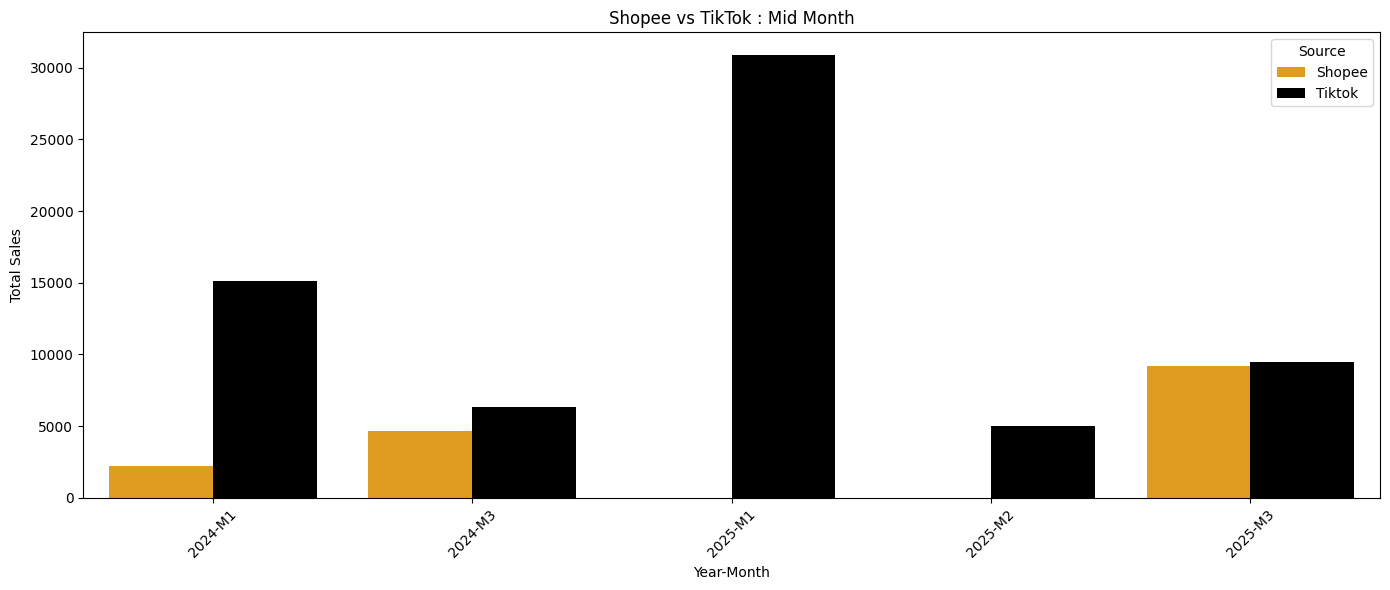

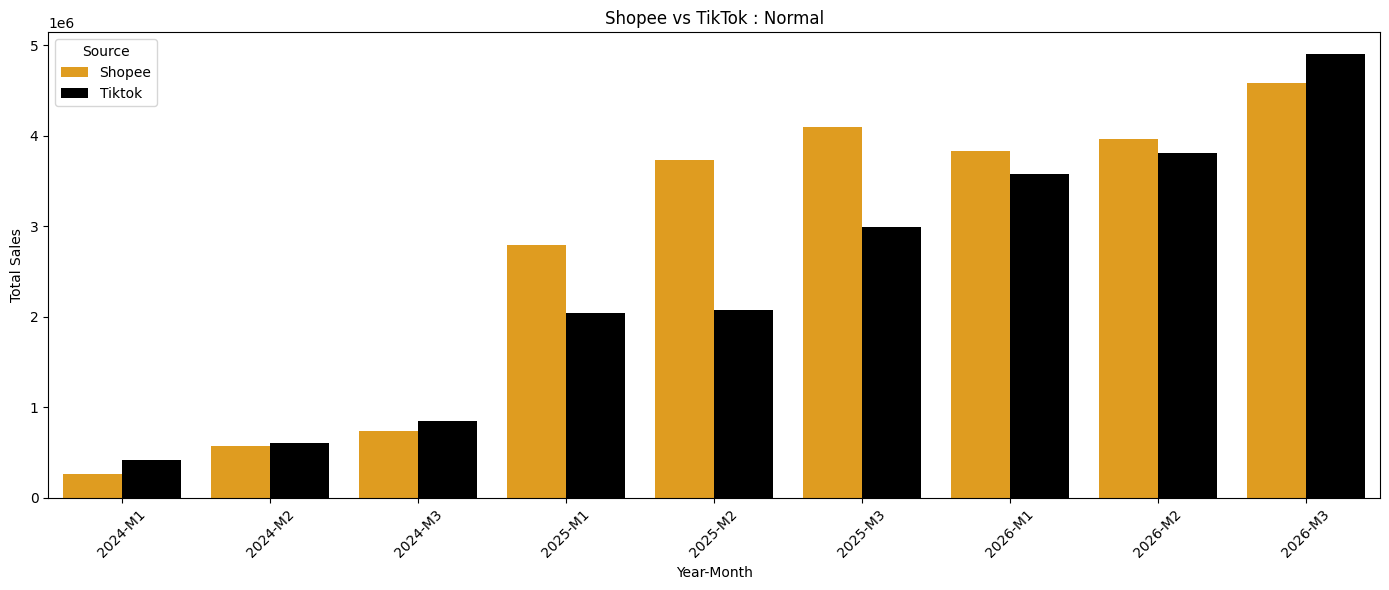

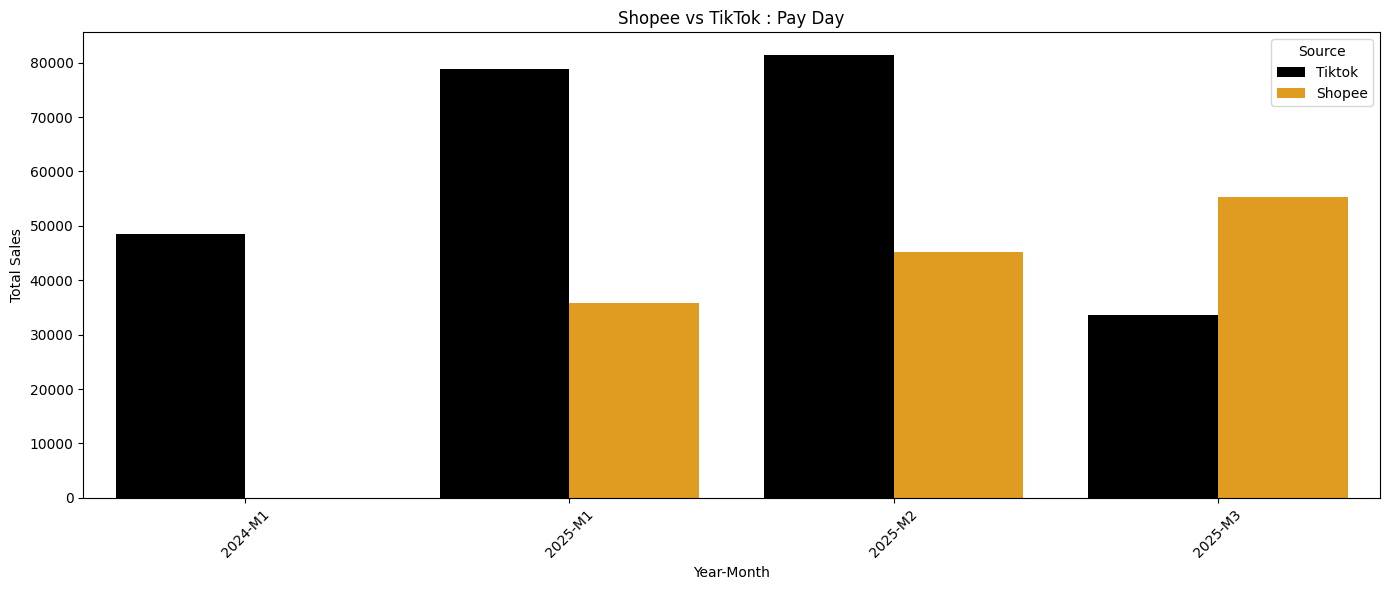

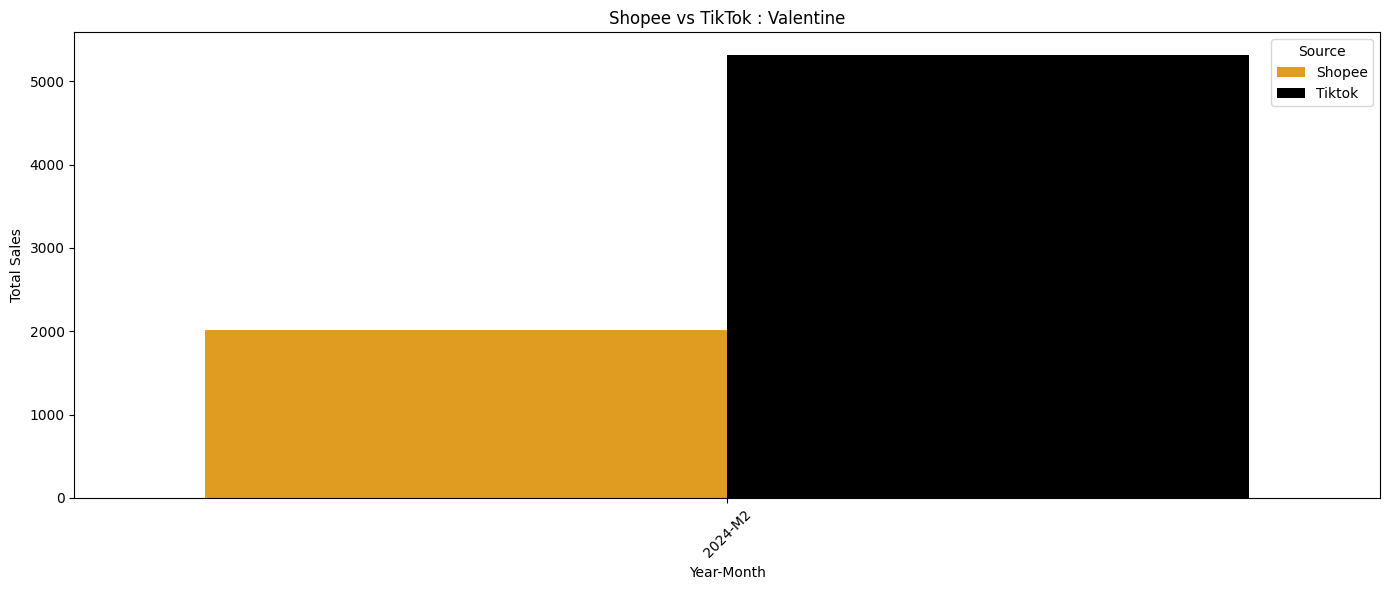

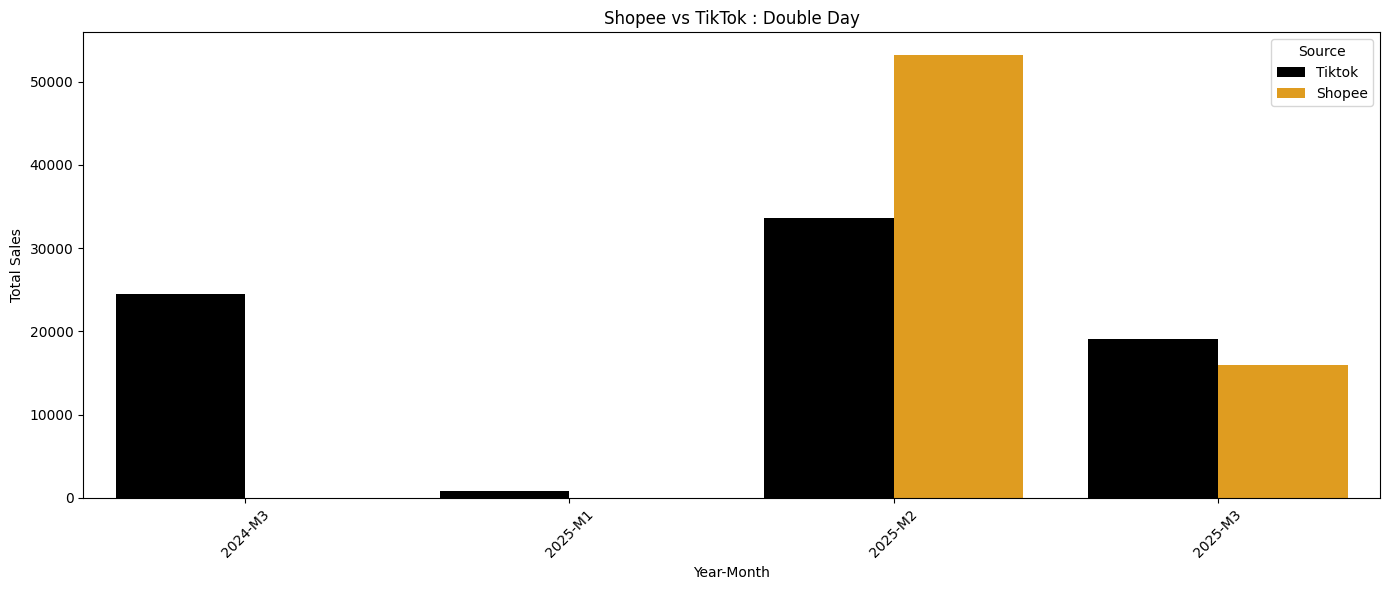

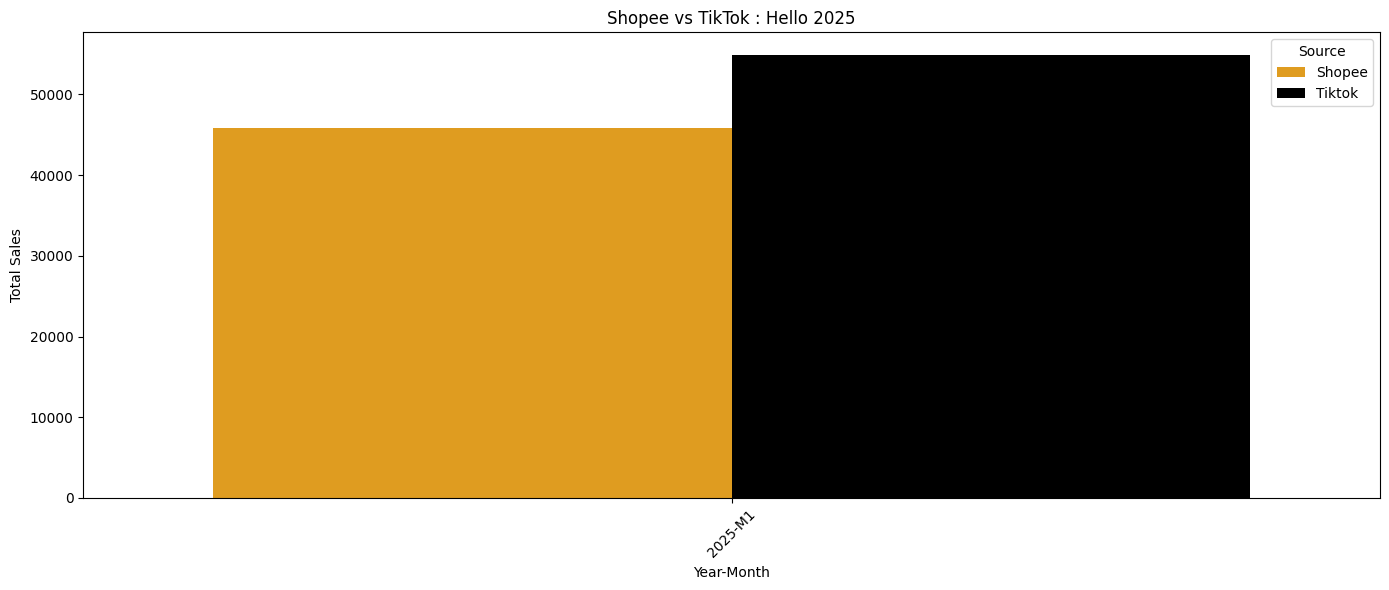

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# LOAD DATA
# =========================

# ถ้าเป็น csv
# df = pd.read_csv("df_combined_final.csv")

# ถ้า dataframe อยู่แล้ว
df = df_combined_final.copy()

# =========================
# PREPARE DATE
# =========================

# สมมติว่ามีคอลัมน์ Date
# ถ้ายังไม่ใช่ datetime ให้แปลงก่อน

df['Date'] = pd.to_datetime(df['Created Time'])

df['Year'] = df['Created Time'].dt.year
df['Month'] = df['Created Time'].dt.month

# =========================
# FILTER YEAR + MONTH
# =========================

df = df[
    (df['Year'].isin([2024, 2025, 2026])) &
    (df['Month'].isin([1, 2, 3]))
]

# =========================
# STANDARDIZE CAMPAIGN NAME
# =========================

# copy จาก Mecanic_cam มาก่อน
df['Campaign_compare'] = df['Mecanic_cam'].copy()

# normalize ชื่อ campaign
campaign_map = {
    'Flash Sell': 'Flash Sale',
    'Flash sale': 'Flash Sale',
    'PayDay': 'Pay Day',
    'Mid month': 'Mid Month',
}

df['Campaign_compare'] = (
    df['Campaign_compare']
    .replace(campaign_map)
)

# =========================
# ADD VALENTINE FROM SHOPEE
# =========================

# ถ้า Product Name มีคำว่า Valentine Set
# ให้ assign เป็น Valentine

valentine_mask = (
    (df['Source'] == 'Shopee') &
    (
        df['Product Name']
        .astype(str)
        .str.contains(
            'Valentine Set',
            case=False,
            na=False
        )
    )
)

df.loc[valentine_mask, 'Campaign_compare'] = 'Valentine'
# =========================
# KEEP ONLY CAMPAIGNS
# THAT EXIST IN BOTH PLATFORM
# =========================

platform_count = (
    df.groupby('Campaign_compare')['Source']
    .nunique()
)

common_campaigns = platform_count[platform_count >= 2].index

df = df[df['Campaign_compare'].isin(common_campaigns)]

# =========================
# AGGREGATE SALES
# =========================

summary = (
    df.groupby(
        ['Year', 'Month', 'Campaign_compare', 'Source'],
        as_index=False
    )['Total_sale']
    .sum()
)

# =========================
# CREATE LABEL
# =========================

summary['Period'] = (
    summary['Year'].astype(str)
    + '-M' +
    summary['Month'].astype(str)
)

# =========================
# PLOT 1:
# GROUPED BAR CHART
# =========================

campaigns = summary['Campaign_compare'].unique()

# Define custom color palette
color_palette = {'Shopee': 'orange', 'Tiktok': 'black'}

for camp in campaigns:

    temp = summary[
        summary['Campaign_compare'] == camp
    ]

    plt.figure(figsize=(14,6))

    sns.barplot(
        data=temp,
        x='Period',
        y='Total_sale',
        hue='Source',
        palette=color_palette  # Apply the custom palette
    )

    plt.title(f'Shopee vs TikTok : {camp}')
    plt.xticks(rotation=45)
    plt.ylabel('Total Sales')
    plt.xlabel('Year-Month')

    plt.tight_layout()
    plt.show()

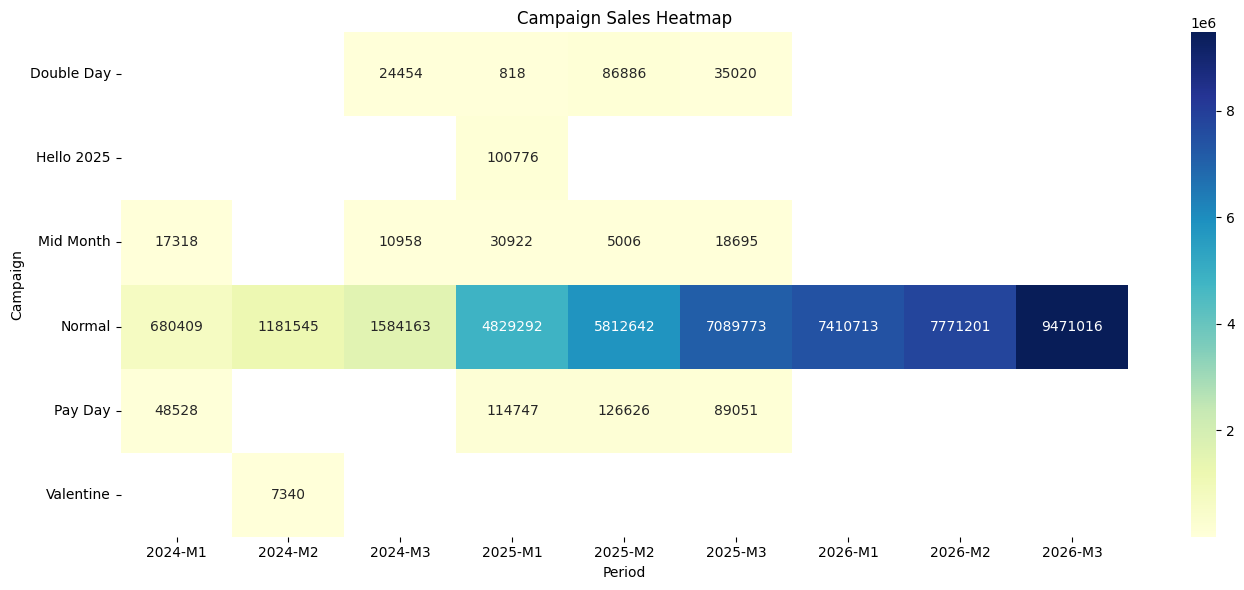

In [18]:
# =========================
# PLOT 2:
# HEATMAP
# =========================

heatmap_df = (
    summary.groupby(
        ['Campaign_compare', 'Period']
    )['Total_sale']
    .sum()
    .unstack()
)

plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu'
)

plt.title('Campaign Sales Heatmap')
plt.xlabel('Period')
plt.ylabel('Campaign')

plt.tight_layout()
plt.show()